In [165]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [166]:
df=pd.read_csv("gurgaon_properties_cleaned_v2.csv")

In [167]:
df.head()

,property_type,society,sector,price_in_crore,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja ghar,others,furnishing_type,luxury_score
0,flat,smriti apartment,56,0.45,7500.0,600.0,Super Built up area 600(55.74 sq.m.),1,1,2,...,600.0,NaN,NaN,0,0,0,0,0,1,57
1,flat,signature global park,48,0.54,7200.0,750.0,Carpet area: 750 (69.68 sq.m.),2,2,2,...,NaN,NaN,750.0,0,0,0,0,0,1,111
2,flat,ats triumph,104,1.85,8078.0,2290.0,Super Built up area 2290(212.75 sq.m.),3,4,3+,...,2290.0,NaN,NaN,1,1,1,0,0,1,117
3,flat,pareena laxmi apartments,99,0.32,6106.0,524.0,Super Built up area 524(48.68 sq.m.)Carpet are...,2,2,2,...,524.0,NaN,424.8,0,0,0,0,0,1,50
4,flat,m3m woodshire,107,1.40,5929.0,2361.0,Super Built up area 2361(219.34 sq.m.),3,4,0,...,2361.0,NaN,NaN,0,0,0,0,0,1,67


In [168]:
df.shape

(3951, 23)

In [169]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3951 entries, 0 to 3950
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   property_type        3951 non-null   object 
 1   society              3950 non-null   object 
 2   sector               3951 non-null   int64  
 3   price_in_crore       3931 non-null   float64
 4   price_per_sqft       3931 non-null   float64
 5   area                 3931 non-null   float64
 6   areaWithType         3951 non-null   object 
 7   bedRoom              3951 non-null   int64  
 8   bathroom             3951 non-null   int64  
 9   balcony              3951 non-null   object 
 10  floorNum             3930 non-null   float64
 11  facing               2781 non-null   object 
 12  agePossession        3951 non-null   object 
 13  super_built_up_area  1933 non-null   float64
 14  built_up_area        1840 non-null   float64
 15  carpet_area          2002 non-null   f

In [170]:
df.duplicated().sum()

np.int64(129)

In [171]:
df.drop_duplicates(inplace=True)

## 1.property type

<Axes: xlabel='property_type'>

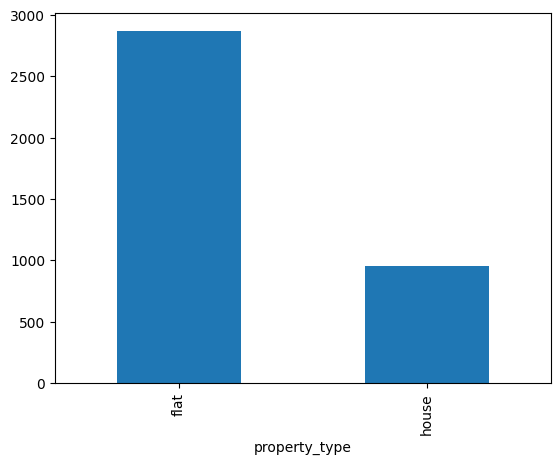

In [172]:
df['property_type'].value_counts().plot(kind='bar')

## Observation
 flats are in majority and there are less number of houses
 
no missing value

### 2. Society

In [173]:
df['society'].value_counts().shape

(723,)

In [174]:
df['society'].value_counts()

society
independent                             562
tulip violet                             75
ss the leaf                              73
shapoorji pallonji joyville gurugram     42
dlf new town heights                     42
                                       ... 
cghs hewo apartments                      1
smart world one dxp                       1
bajrang apartments                        1
farrukhnagar                              1
huda plot sector 38                       1
Name: count, Length: 723, dtype: int64

In [175]:
df[df['society']!='independent']['society'].value_counts(normalize=True).cumsum().head(75)

society
tulip violet                            0.023013
ss the leaf                             0.045413
shapoorji pallonji joyville gurugram    0.058300
dlf new town heights                    0.071187
signature global park                   0.081927
                                          ...   
ats kocoon                              0.480209
umang winter hills                      0.484198
umang monsoon breeze                    0.488187
central park flower valley              0.491869
ireo the corridors                      0.495551
Name: proportion, Length: 75, dtype: float64

In [176]:
society_counts=df['society'].value_counts()
#frequency distribution for societies
frequency_bias={
    "Very High(>100)":(society_counts>100).sum(),
    "High (50-100)":((society_counts>=50) & (society_counts<=100)).sum(),
    "Average(10-49)":((society_counts>=10) & (society_counts<=49)).sum(),
    "Low (2-9)":((society_counts>=2) & (society_counts<=9)).sum(),
    "Very Low (1)":(society_counts==1).sum()
}
frequency_bias

{'Very High(>100)': np.int64(1),
 'High (50-100)': np.int64(2),
 'Average(10-49)': np.int64(92),
 'Low (2-9)': np.int64(286),
 'Very Low (1)': np.int64(342)}

<Axes: xlabel='society'>

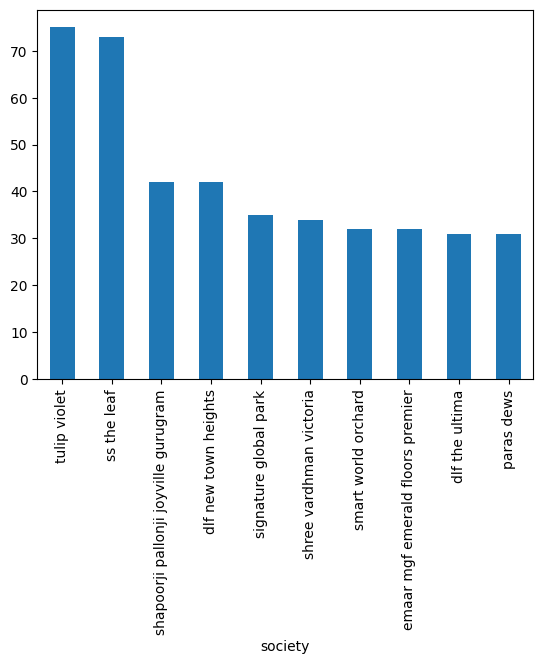

In [177]:
#top 10 societies
df[df['society']!='independent']['society'].value_counts().head(10).plot(kind='bar')

In [178]:
df['society'].isnull().sum()

np.int64(1)

In [179]:
df[df['society'].isnull()]

,property_type,society,sector,price_in_crore,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja ghar,others,furnishing_type,luxury_score
488,flat,NaN,78,0.6,3692.0,1625.0,Built Up area: 1625 (150.97 sq.m.),2,2,0,...,NaN,1625.0,NaN,0,0,0,0,0,1,0


### observations
1. around 13% properties comes under independent tag
2. there are 723 societies
3. the top 75 societies have 50 percent of the properties and the rest 50 percent of the properties comes under the remaining socities
4. Very High(>100) : only 1 society has more than 100 listings
5. High (50-100) : 2 societies have between 50 to 100 listings
6. Average(10-49) : 92 societies have between 10 to 49 listings
7. Low (2-9) : 286 societies have between 2 to 9 listings
8. Very Low (1): 342 societies have only 1 listings
9. 1 missing value

### Sector

In [180]:
#unique sectors
df['sector'].value_counts().shape


(99,)

<Axes: xlabel='sector'>

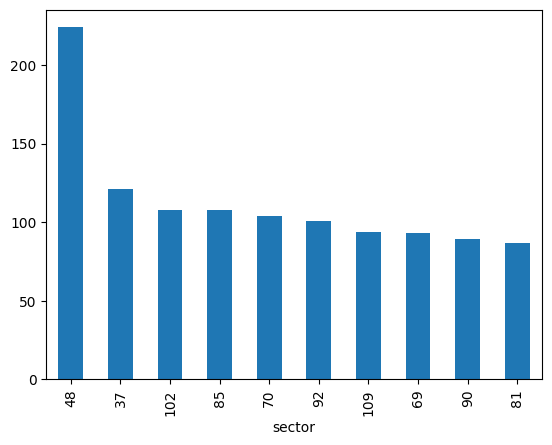

In [109]:
#top 10 sector
df['sector'].value_counts().head(10).plot(kind='bar')

In [110]:
sector_counts=df['sector'].value_counts()
#frequency distribution for sector
sector_frequency_bias={
    "Very High(>100)":(sector_counts>100).sum(),
    "High (50-100)":((sector_counts>=50) & (sector_counts<=100)).sum(),
    "Average(10-49)":((sector_counts>=10) & (sector_counts<=49)).sum(),
    "Low (2-9)":((sector_counts>=2) & (sector_counts<=9)).sum(),
    "Very Low (1)":(sector_counts==1).sum()
}
sector_frequency_bias

{'Very High(>100)': np.int64(6),
 'High (50-100)': np.int64(24),
 'Average(10-49)': np.int64(57),
 'Low (2-9)': np.int64(9),
 'Very Low (1)': np.int64(3)}

### observations
1. there are 999 societies
2. Very High(>100) : only 6 sector has more than 100 listings
3. High (50-100) : 24 sector have between 50 to 100 listings
4. Average(10-49) : 57 sector have between 10 to 49 listings
5. Low (2-9) : 9 sector have between 2 to 9 listings
6. Very Low (1): 3 sector have only 1 listings

### price

In [111]:
df['price_in_crore'].isnull().sum()


np.int64(19)

In [112]:
df['price_in_crore'].describe()

count    3803.000000
mean        2.504552
std         2.955153
min         0.070000
25%         0.920000
50%         1.500000
75%         2.700000
max        31.500000
Name: price_in_crore, dtype: float64

<Axes: xlabel='price_in_crore', ylabel='Count'>

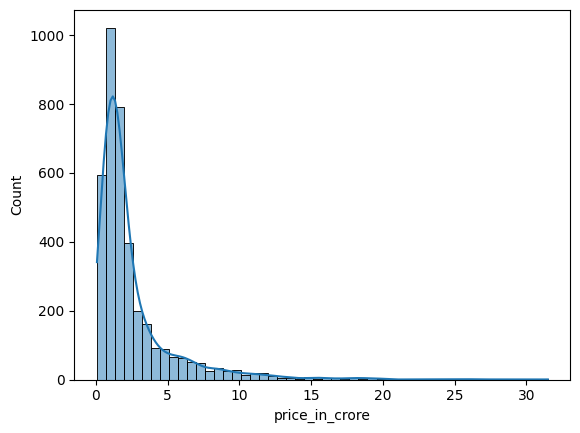

In [113]:
sns.histplot(df['price_in_crore'],kde=True,bins=50)

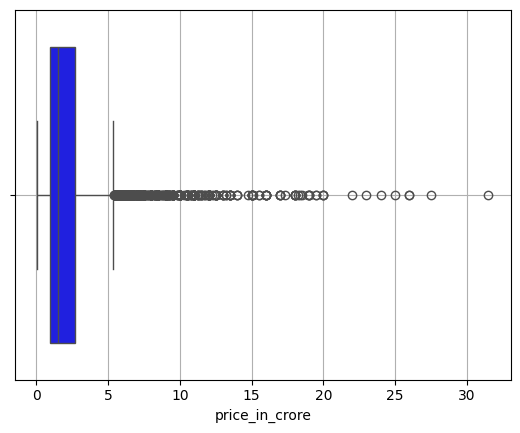

In [114]:
sns.boxplot(x=df['price_in_crore'],color='blue')
plt.grid()

### Descriptive Statistics:
1. Count: There are 3,803 non-missing price entries.
2. Mean Price: The average price is approximately 2.50 crores.
3. Median Price: The median (50th percentile) price is 1.50 crores.
4. Standard Deviation: The prices have a standard deviation of 2.96, indicating variability in the prices.
5. Range: Prices range from a minimum of 0.07 crores to a maximum of 31.5 crores.
6. IQR: The interquartile range (difference between the 75th and 25th percentile) ranges from 0.92 crores to 2.70 crores.

### Visualizations:
1. Distribution: The histogram indicates that most properties are priced in the lower range (below 5 crores), with a few properties going beyond 10 crores.
2. Box Plot: The box plot showcases the spread of the data and potential outliers. Properties priced above approximately 10 crores might be considered outliers as they lie beyond the upper whisker of the box plot.

 Missing Values: There are 19 missing values in the price column.


In [115]:
#skewness and kurtosis
skewness=df['price_in_crore'].skew()
kurtosis=df['price_in_crore'].kurt()
print(skewness,kurtosis)

3.2959671988867068 15.125331565241869


### Skewness: 
The price distribution has a skewness of approximately 3.30, indicating a positive skew. This means that the distribution tail is skewed to the right, which aligns with the observation from the histogram where most properties have prices on the lower end with a few high-priced properties.

### Kurtosis: 
The kurtosis value is approximately 15.13. A kurtosis value greater than 3 indicates a distribution with heavier tails and more outliers compared to a normal distribution.

In [116]:
# Quantile Analysis
quantiles = df['price_in_crore'].quantile([0.01, 0.05, 0.95, 0.99])

quantiles

0.01     0.250
0.05     0.370
0.95     8.490
0.99    15.098
Name: price_in_crore, dtype: float64

### Quantile Analysis:

1. 1% Quantile: Only 1% of properties are priced below 0.25 crores.
2. 5% Quantile: 5% of properties are priced below 0.37 crores.
3. 95% Quantile: 95% of properties are priced below 8.49 crores.
4. 99% Quantile: 99% of properties are priced below 15.10 crores, indicating that very few properties are priced above this value.

In [117]:
# Identify potential outliers using IQR method
Q1 = df['price_in_crore'].describe()['25%']
Q3 = df['price_in_crore'].describe()['75%']
IQR = Q3 - Q1

IQR

np.float64(1.7800000000000002)

In [118]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(lower_bound, upper_bound)

-1.7500000000000004 5.370000000000001


In [119]:
outliers = df[(df['price_in_crore'] < lower_bound) | (df['price_in_crore'] > upper_bound)]
outliers.shape

(439, 23)

In [120]:
outliers['price_in_crore'].describe()

count    439.000000
mean       9.164556
std        4.049009
min        5.400000
25%        6.350000
50%        8.000000
75%       10.550000
max       31.500000
Name: price_in_crore, dtype: float64

###**Outliers Analysis (using IQR method):**
1. Based on the IQR method, there are **439** properties considered as outliers.
2. These outliers have an average price of approximately **9.16 crores**.
3. The range for these outliers is from **5.4 crores to 31.5 crores**.

<Axes: xlabel='price_in_crore'>

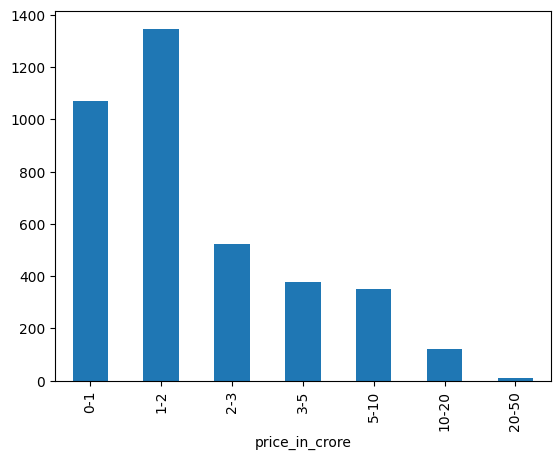

In [121]:
# price binning
bins = [0, 1, 2, 3, 5, 10, 20, 50]
bin_labels = ["0-1", "1-2", "2-3", "3-5", "5-10", "10-20", "20-50"]
pd.cut(df['price_in_crore'], bins=bins, labels=bin_labels, right=False).value_counts().sort_index().plot(kind='bar')

1. The majority of properties are priced in the **"1–2 crores"** and **"2–3 crores"** ranges.
2. There is a significant drop in the number of properties priced above **5 crores**, indicating that high-priced properties are relatively less common in the dataset.


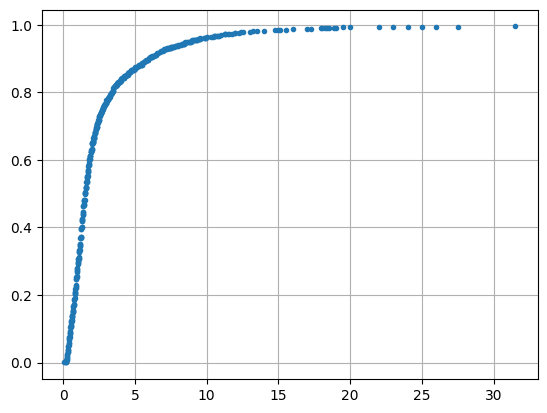

In [122]:
# ecdf plot
ecdf = df['price_in_crore'].value_counts().sort_index().cumsum() / len(df['price_in_crore'])
plt.plot(ecdf.index, ecdf, marker='.', linestyle='none')
plt.grid()

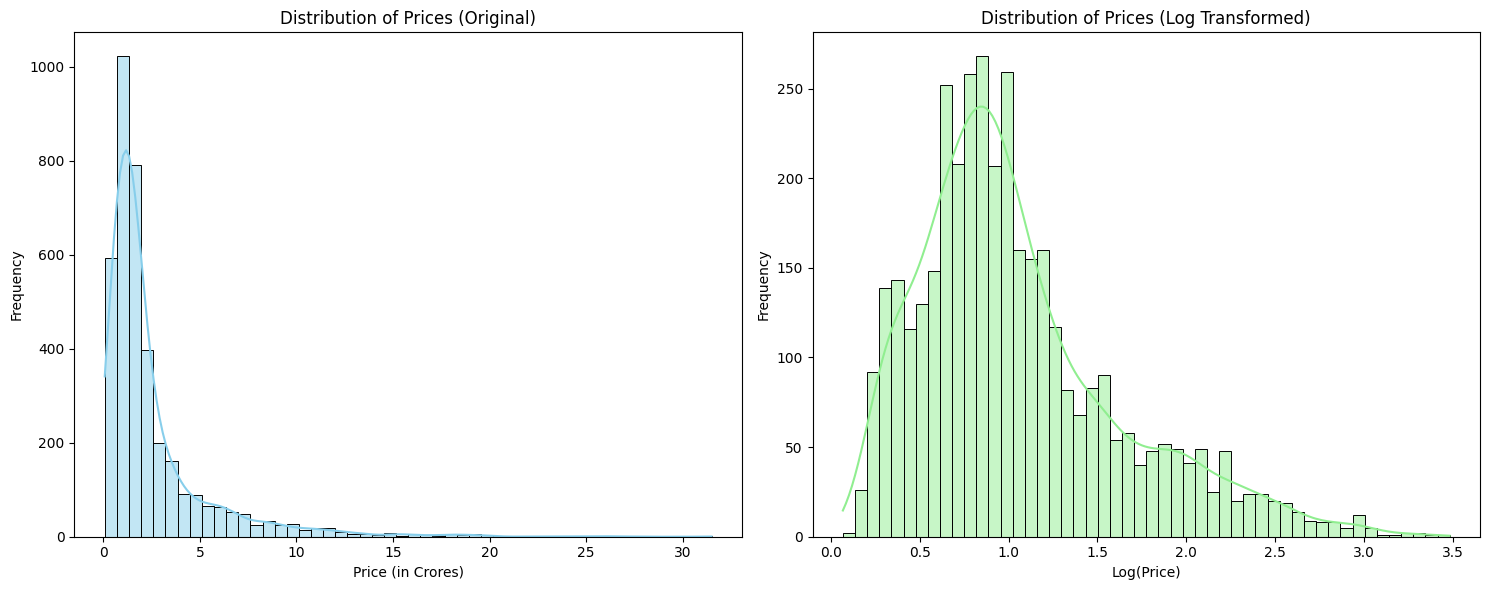

In [123]:
plt.figure(figsize=(15, 6))

# Distribution plot without log transformation
plt.subplot(1, 2, 1)
sns.histplot(df['price_in_crore'], kde=True, bins=50, color='skyblue')
plt.title('Distribution of Prices (Original)')
plt.xlabel('Price (in Crores)')
plt.ylabel('Frequency')

# Distribution plot with log transformation
plt.subplot(1, 2, 2)
sns.histplot(np.log1p(df['price_in_crore']), kde=True, bins=50, color='lightgreen')
plt.title('Distribution of Prices (Log Transformed)')
plt.xlabel('Log(Price)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

np.log1p(x): This function computes the natural logarithm of 1+x. 
It's designed to provide more accurate results for values of x that are very close to zero.

Using np.log1p helps in transforming the price column while ensuring that any value (including zero, if present) is handled appropriately. When we need to reverse the transformation, we can use np.expm1 which computes e^x-1

In [124]:
skewness = np.log1p(df['price_in_crore']).skew()
kurtosis = np.log1p(df['price_in_crore']).kurt()

print(skewness,kurtosis)

1.0748939214067503 0.9708504323279707


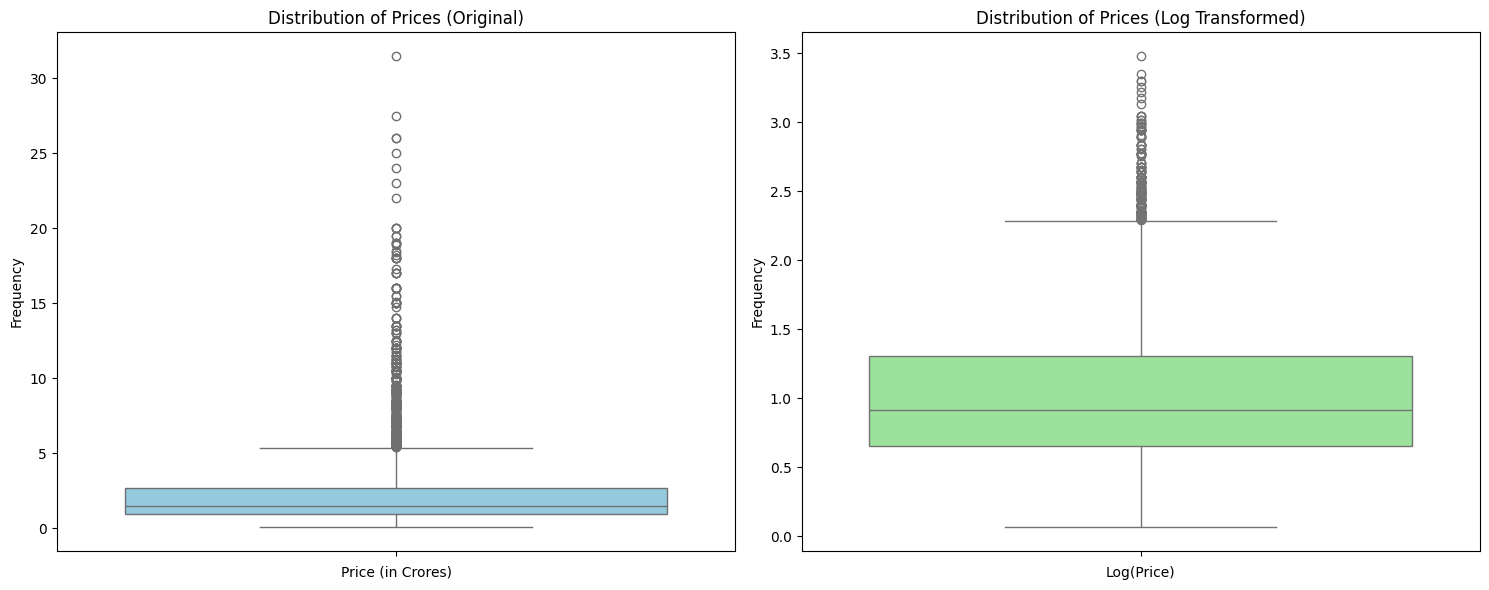

In [125]:
plt.figure(figsize=(15, 6))

# Distribution plot without log transformation
plt.subplot(1, 2, 1)
sns.boxplot(df['price_in_crore'], color='skyblue')
plt.title('Distribution of Prices (Original)')
plt.xlabel('Price (in Crores)')
plt.ylabel('Frequency')

# Distribution plot with log transformation
plt.subplot(1, 2, 2)
sns.boxplot(np.log1p(df['price_in_crore']), color='lightgreen')
plt.title('Distribution of Prices (Log Transformed)')
plt.xlabel('Log(Price)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

### price_per_sqft

In [126]:
df['price_per_sqft'].isnull().sum()

np.int64(19)

In [127]:
df['price_per_sqft'].describe()

count      3803.000000
mean      14019.157244
std       23371.694484
min           2.000000
25%        6809.500000
50%        9011.000000
75%       13870.000000
max      600000.000000
Name: price_per_sqft, dtype: float64

<Axes: xlabel='price_per_sqft', ylabel='Count'>

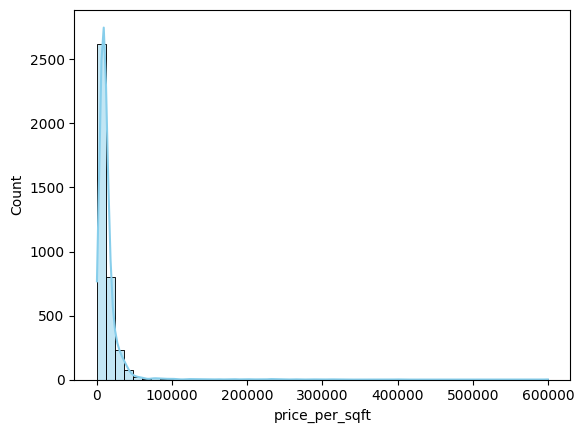

In [128]:
sns.histplot(df['price_per_sqft'], bins=50, color='skyblue', kde=True)

Most properties have a price_per_sqft ranging between approximately ₹0 and ₹10,000. There is a significant concentration in the lower range, with a few properties having exceptionally high price_per_sqft.

<Axes: ylabel='price_per_sqft'>

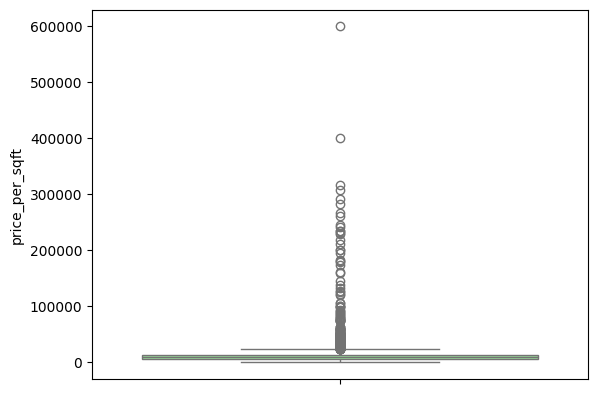

In [129]:
sns.boxplot(df['price_per_sqft'], color='lightgreen')

The box plot clearly shows several outliers, especially on the higher side. The interquartile range (IQR) is relatively compact, but there are many data points beyond the "whiskers" of the box plot, indicating potential outliers

#### Observations

- Potential Outliers
- Right Skewed
- 19 missing values

### bedRoom

In [130]:
df['bedRoom'].isnull().sum()

np.int64(0)

<Axes: xlabel='bedRoom'>

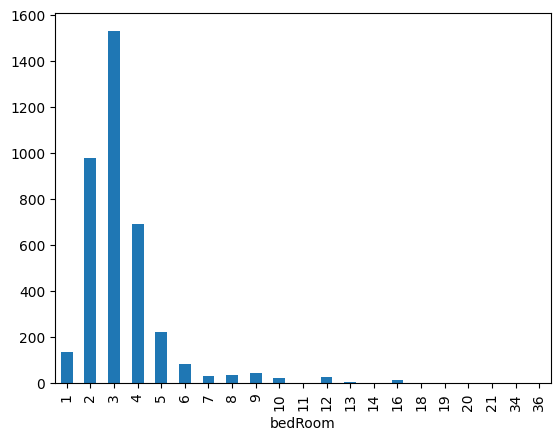

In [131]:
df['bedRoom'].value_counts().sort_index().plot(kind='bar')

<Axes: ylabel='proportion'>

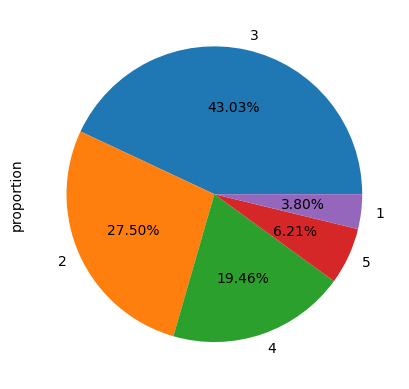

In [185]:
df['bedRoom'].value_counts(normalize=True).head().plot(kind='pie',autopct='%0.2f%%')

### bathroom

In [133]:
df['bathroom'].isnull().sum()

np.int64(0)

<Axes: xlabel='bathroom'>

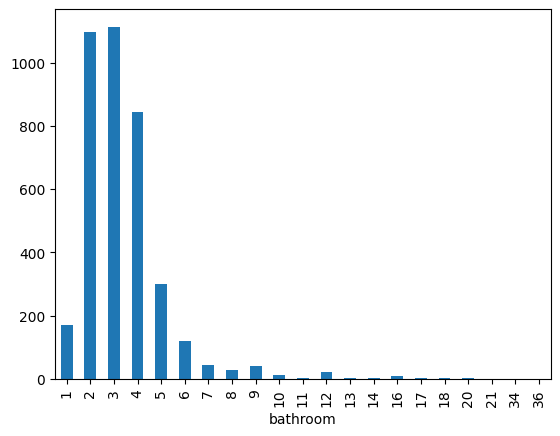

In [134]:
df['bathroom'].value_counts().sort_index().plot(kind='bar')

<Axes: ylabel='proportion'>

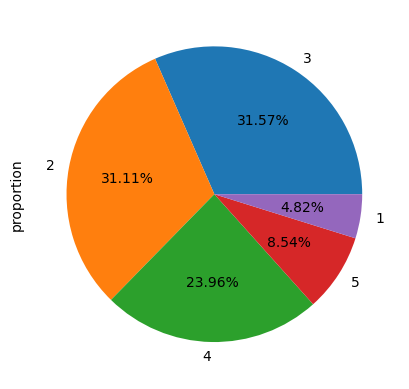

In [135]:
df['bathroom'].value_counts(normalize=True).head().plot(kind='pie',autopct='%0.2f%%')

### balcony

In [136]:
df['balcony'].isnull().sum()

np.int64(0)

<Axes: xlabel='balcony'>

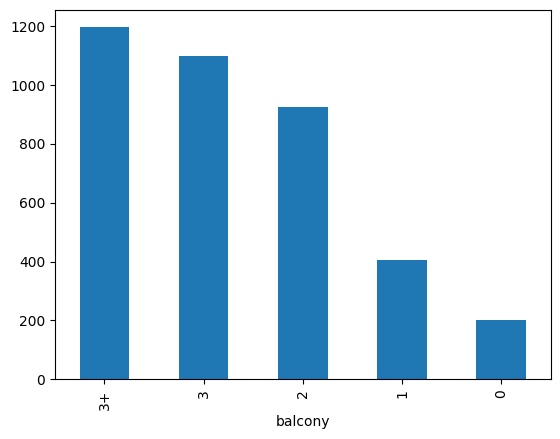

In [137]:
df['balcony'].value_counts().plot(kind='bar')

<Axes: ylabel='proportion'>

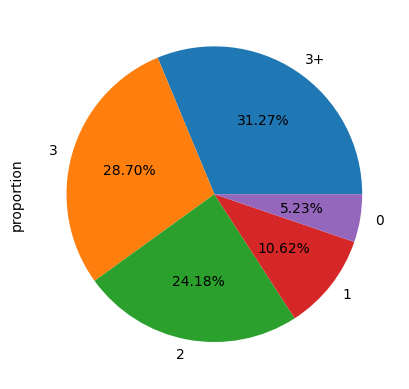

In [138]:
df['balcony'].value_counts(normalize=True).head().plot(kind='pie',autopct='%0.2f%%')

### floorNum

In [139]:
df.iloc[:,10:].head()

,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja ghar,others,furnishing_type,luxury_score
0,3.0,NaN,Old Property,600.0,NaN,NaN,0,0,0,0,0,1,57
1,4.0,North-East,Under Construction,NaN,NaN,750.0,0,0,0,0,0,1,111
2,14.0,East,Relatively New,2290.0,NaN,NaN,1,1,1,0,0,1,117
3,2.0,NaN,New Property,524.0,NaN,424.8,0,0,0,0,0,1,50
4,1.0,East,New Property,2361.0,NaN,NaN,0,0,0,0,0,1,67


In [140]:
df['floorNum'].isnull().sum()

np.int64(21)

In [141]:
df['floorNum'].describe()

count    3801.000000
mean        6.665088
std         5.994705
min         0.000000
25%         2.000000
50%         4.000000
75%        10.000000
max        51.000000
Name: floorNum, dtype: float64

<Axes: xlabel='floorNum'>

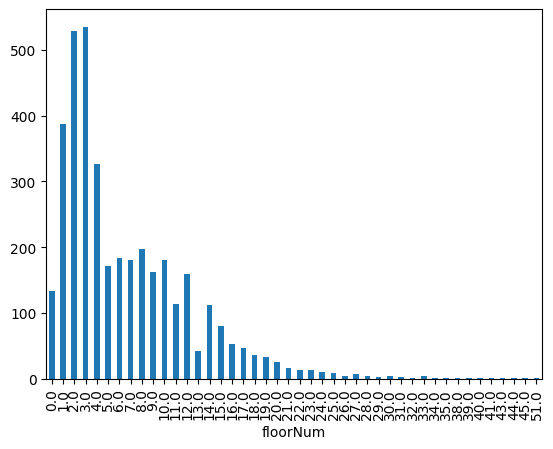

In [142]:
df['floorNum'].value_counts().sort_index().plot(kind='bar')

<Axes: ylabel='floorNum'>

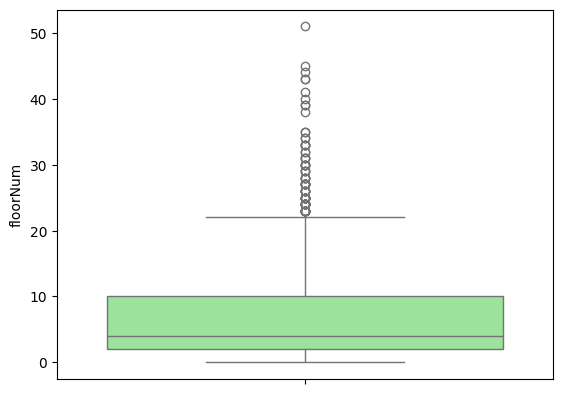

In [143]:
sns.boxplot(df['floorNum'], color='lightgreen')

- The majority of the properties lie between the ground floor (0) and the 25th floor.
- Floors 1 to 4 are particularly common, with the 3rd floor being the most frequent.
- There are a few properties located at higher floors, but their frequency is much lower.
- The box plot reveals that the majority of the properties are concentrated around the lower floors. The interquartile range (IQR) lies between approximately the 2nd and 10th floors.
- Data points beyond the "whiskers" of the box plot, especially on the higher side, indicate potential outliers.

### facing

In [144]:
df['facing'].isnull().sum()

np.int64(1108)

In [145]:
df['facing'].fillna('NA',inplace=True)

C:\Users\palas\AppData\Local\Temp\ipykernel_25260\3692945726.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['facing'].fillna('NA',inplace=True)


In [146]:
df['facing'].value_counts()

facing
NA            1108
East           648
North-East     645
North          399
West           252
South          235
North-West     198
South-East     182
South-West     155
Name: count, dtype: int64

### agePossession

In [147]:
df['agePossession'].isnull().sum()

np.int64(0)

In [148]:
df['agePossession'].value_counts()

agePossession
Relatively New        1672
New Property           612
Moderately Old         595
Old Property           344
Undefined              329
Under Construction     270
Name: count, dtype: int64

### areas

In [149]:
# super built up area
df['super_built_up_area'].isnull().sum()

np.int64(1930)

In [150]:
df['super_built_up_area'].describe()

count     1892.000000
mean      1920.820526
std        765.599753
min         89.000000
25%       1465.000000
50%       1828.000000
75%       2215.000000
max      10000.000000
Name: super_built_up_area, dtype: float64

<Axes: xlabel='super_built_up_area', ylabel='Count'>

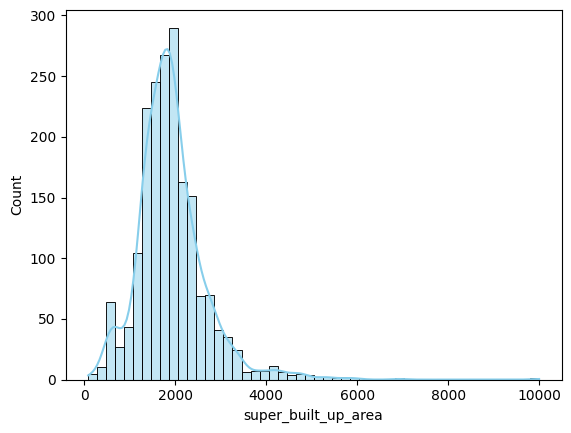

In [151]:
sns.histplot(df['super_built_up_area'].dropna(), bins=50, color='skyblue', kde=True)

<Axes: ylabel='super_built_up_area'>

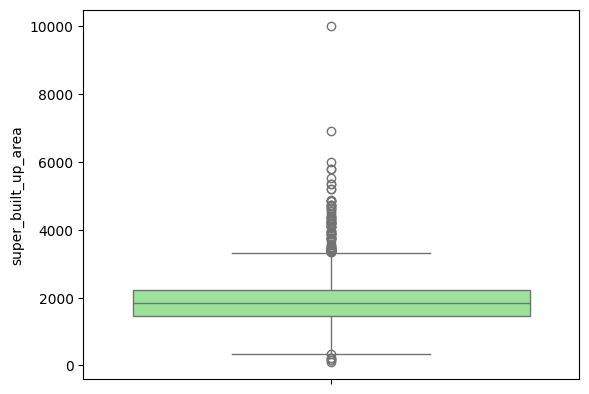

In [152]:
sns.boxplot(df['super_built_up_area'].dropna(), color='lightgreen')

- Most properties have a super built-up area ranging between approximately 1,000 sq.ft and 2,500 sq.ft.
- There are a few properties with a significantly larger area, leading to a right-skewed distribution.
- The interquartile range (IQR) lies between roughly 1,480 sq.ft and 2,215 sq.ft, indicating that the middle 50% of the properties fall within this range.
- There are several data points beyond the upper "whisker" of the box plot, indicating potential outliers. These are properties with an unusually large super built-up area.

### built up area

In [153]:
df['built_up_area'].isnull().sum()

np.int64(2026)

In [154]:
df['built_up_area'].describe()

count      1796.000000
mean       2329.030988
std       17420.083538
min           2.000000
25%        1000.000000
50%        1620.000000
75%        2367.000000
max      737147.000000
Name: built_up_area, dtype: float64

<Axes: xlabel='built_up_area', ylabel='Count'>

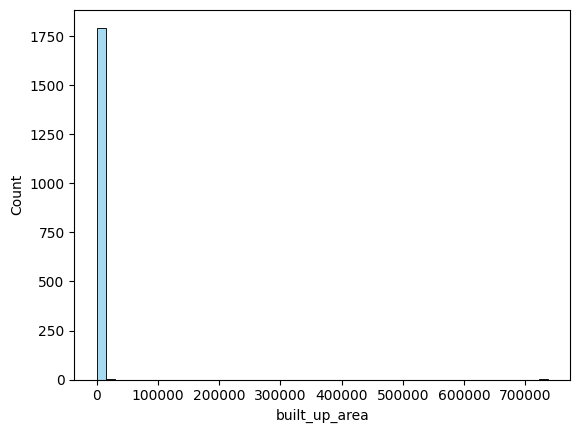

In [155]:
sns.histplot(df['built_up_area'].dropna(), bins=50, color='skyblue', kde=False)

<Axes: ylabel='built_up_area'>

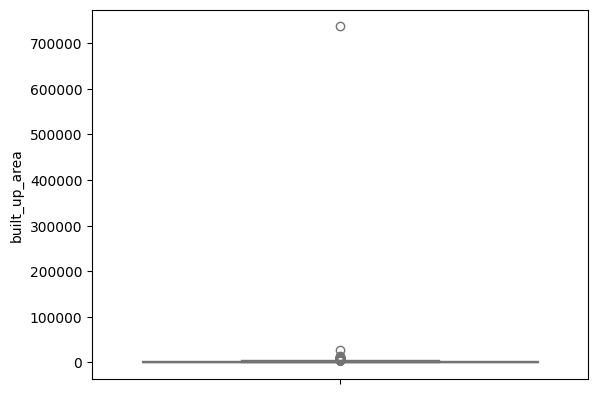

In [156]:
sns.boxplot(df['built_up_area'].dropna(), color='lightgreen')

- Most properties have a built-up area ranging roughly between 500 sq.ft and 3,500 sq.ft.
- There are very few properties with a much larger built-up area, leading to a highly right-skewed distribution.
- The box plot confirms the presence of significant outliers on the higher side. The data's interquartile range (IQR) is relatively compact, but the "whiskers" of the box plot are stretched due to the outliers.


The presence of extreme values, especially on the higher side, suggests that there may be outliers or data errors. This could also be due to some properties being exceptionally large, like a commercial complex or an entire building being listed.

# carpet area

In [157]:
df['carpet_area'].isnull().sum()

np.int64(1894)

In [158]:
df['carpet_area'].describe()

count      1928.000000
mean       2490.670301
std       22467.864233
min          15.000000
25%         822.000000
50%        1286.000000
75%        1786.250000
max      607936.000000
Name: carpet_area, dtype: float64

<Axes: xlabel='carpet_area', ylabel='Count'>

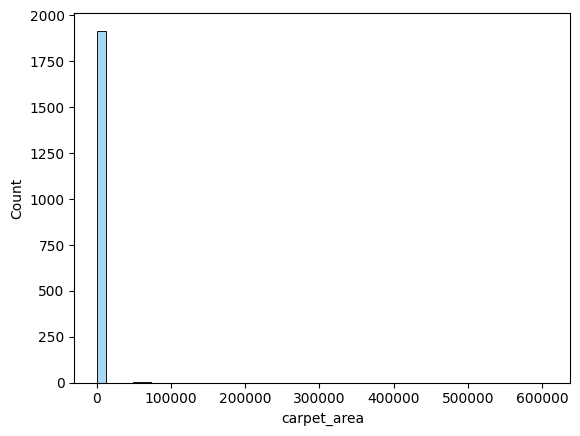

In [159]:
sns.histplot(df['carpet_area'].dropna(), bins=50, color='skyblue', kde=False)

<Axes: ylabel='carpet_area'>

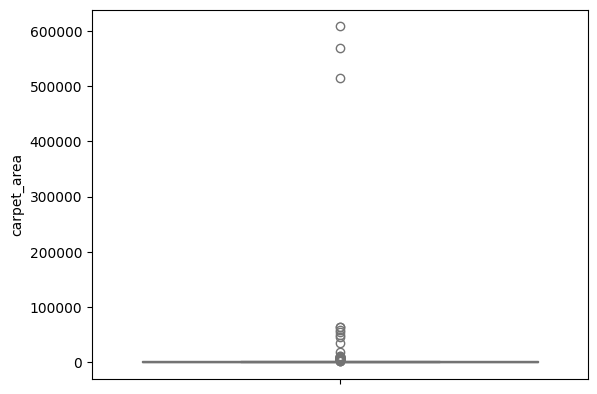

In [160]:
sns.boxplot(df['carpet_area'].dropna(), color='lightgreen')

In [161]:
df.iloc[:,16:]

,study room,servant room,store room,pooja ghar,others,furnishing_type,luxury_score
0,0,0,0,0,0,1,57
1,0,0,0,0,0,1,111
2,1,1,1,0,0,1,117
3,0,0,0,0,0,1,50
4,0,0,0,0,0,1,67
...,...,...,...,...,...,...,...
3944,1,0,0,0,0,0,174
3945,0,1,0,0,0,0,19
3946,0,1,0,0,0,0,152
3949,0,0,0,0,0,1,38


### additional rooms

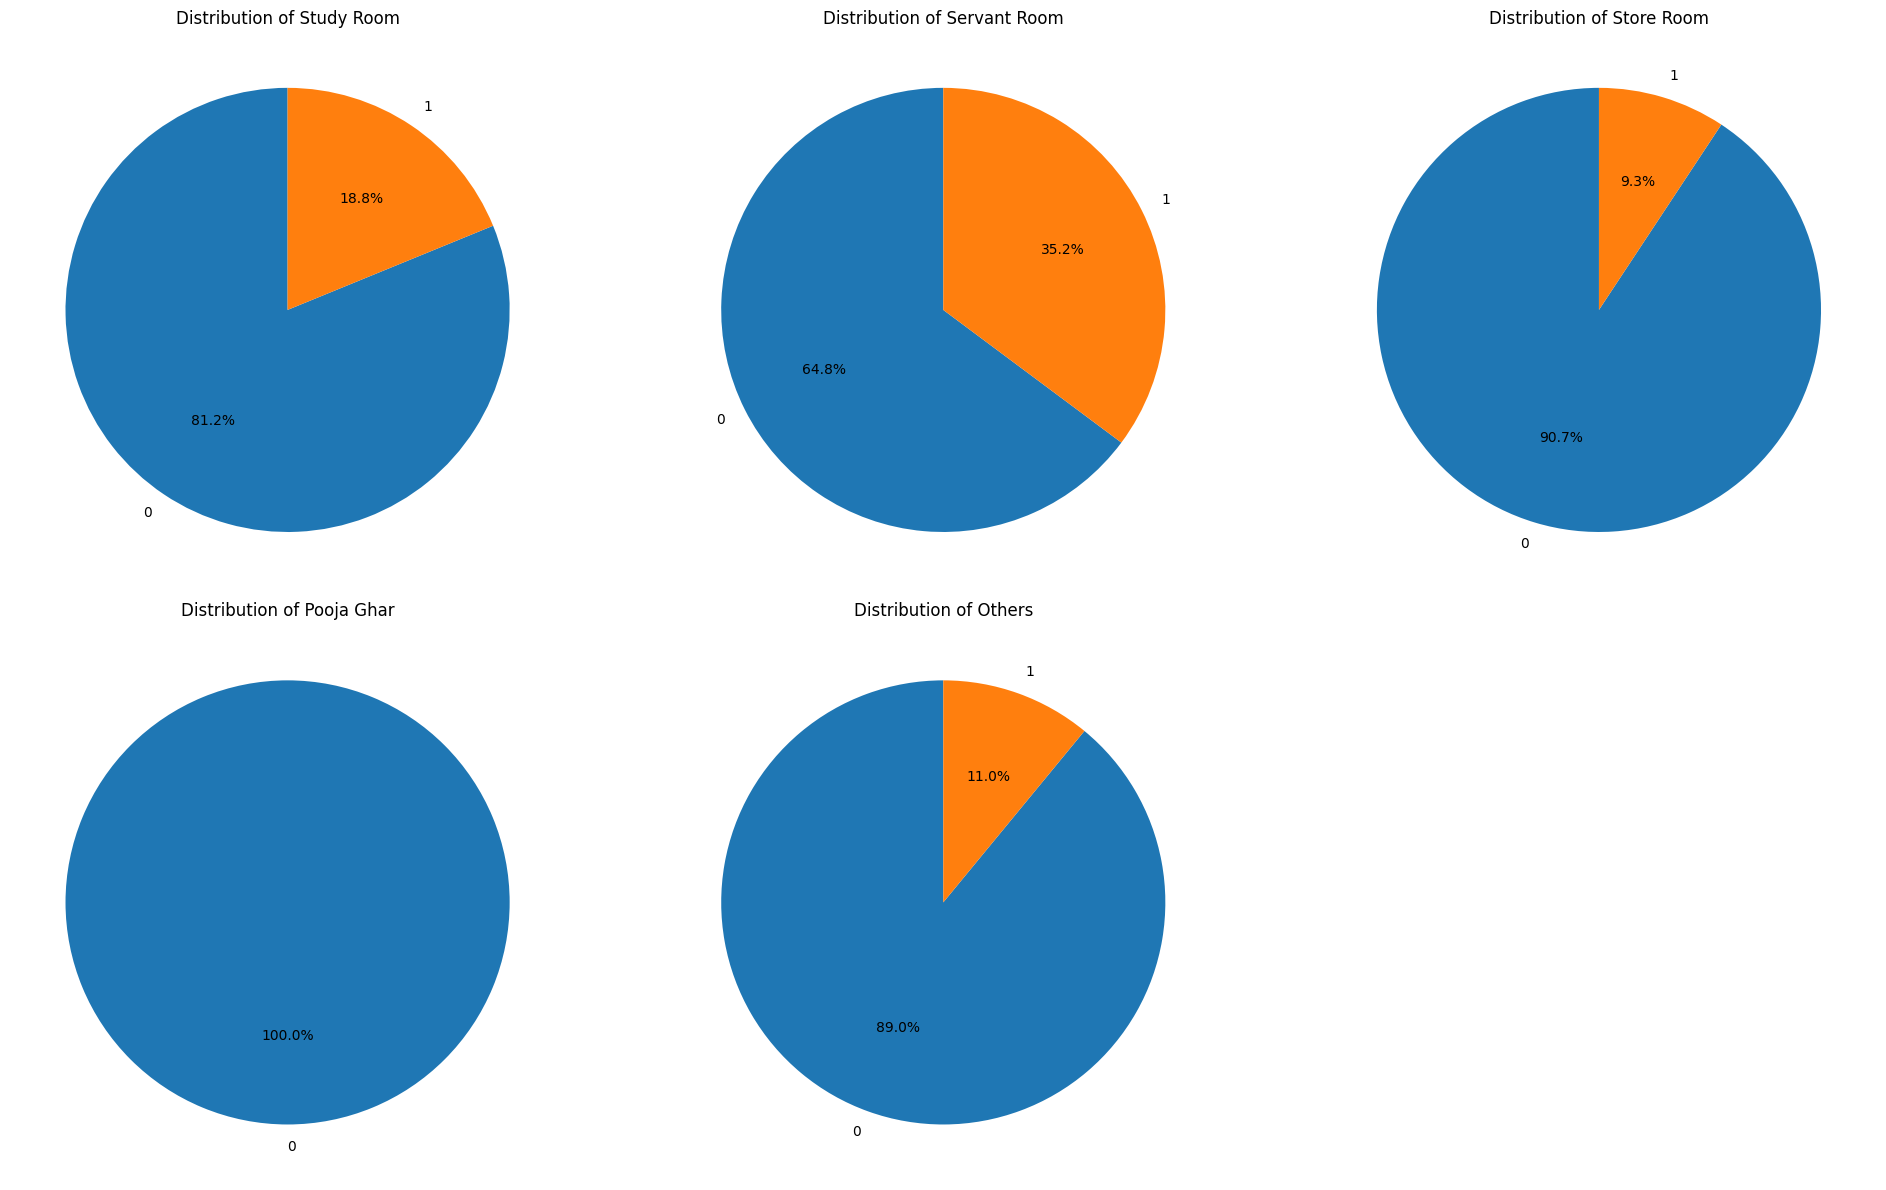

In [162]:
plt.figure(figsize=(20, 12))

# Create a subplot of pie charts for each room type
for idx, room in enumerate(['study room','servant room','store room','pooja ghar','others'], 1):
    ax = plt.subplot(2, 3, idx)
    df[room].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, ax=ax)
    plt.title(f'Distribution of {room.title()}')
    plt.ylabel('')

plt.tight_layout()
plt.show()

### furnishing_type

In [163]:
df['furnishing_type'].value_counts()

furnishing_type
1    2552
0    1062
2     208
Name: count, dtype: int64

<Axes: ylabel='count'>

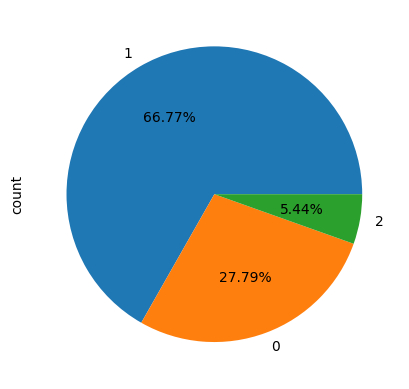

In [164]:
df['furnishing_type'].value_counts().plot(kind='pie',autopct='%0.2f%%')

### luxury score

In [181]:
df['luxury_score'].isnull().sum()

np.int64(0)

In [182]:
df['luxury_score'].describe()

count    3822.000000
mean       69.676609
std        53.221511
min         0.000000
25%        28.000000
50%        56.000000
75%       108.000000
max       174.000000
Name: luxury_score, dtype: float64

<Axes: xlabel='luxury_score', ylabel='Count'>

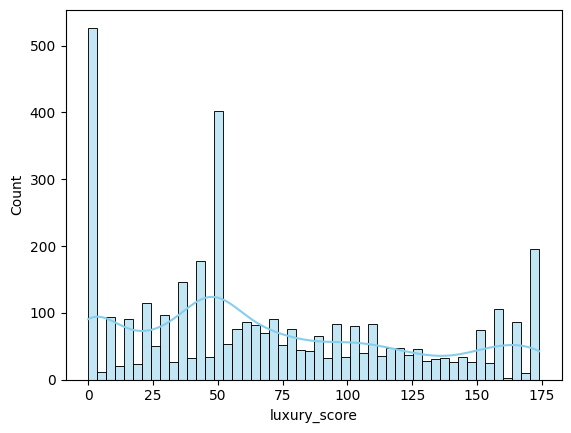

In [183]:
sns.histplot(df['luxury_score'], bins=50, color='skyblue', kde=True)

<Axes: ylabel='luxury_score'>

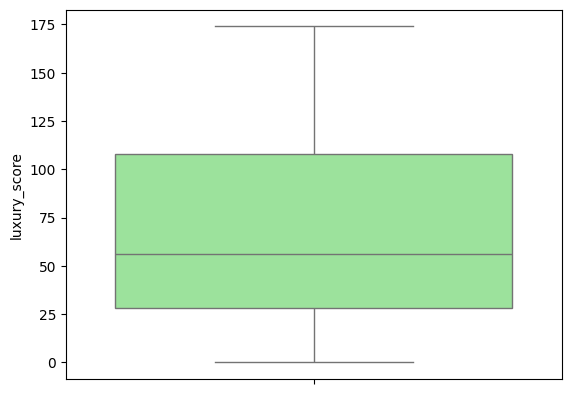

In [184]:
sns.boxplot(df['luxury_score'], color='lightgreen')

The luxury score distribution has multiple peaks, suggesting a multi-modal distribution. There's a significant number of properties with lower luxury scores (around 0-50), and another peak is observed around the 110-130 range.

The box plot reveals that the majority of the properties have luxury scores between approximately 30 and 110. The interquartile range (IQR) lies between these values.